# Inicios


In [1]:
import sys
from pathlib import Path
import pandas as pd
sys.path.insert(0, str(Path.cwd().parents[0] / "src"))

# Criando roteador de LLM


In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
from pydantic import BaseModel, Field
class Test(BaseModel):
    respostas: str = Field(description="Respostas geradas pelo modelo.")

In [4]:
from groq import AsyncGroq
from pydantic import BaseModel
import json
import asyncio
from typing import Optional, Dict, Any, Union
import logging

# Configurar logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# client = Groq()
client = AsyncGroq()

class RouterGroq:
    def __init__(self, messages: str, model_llm: str, strutured_output: Optional[BaseModel] = None):
        self.messages = messages
        self.strutured_output = strutured_output
        self.model_llm = model_llm
    
    async def llm_structured_groq(self) -> Dict[str, Any]:
        """
        Chama modelo Groq com saída estruturada
        
        """
        
        if self.strutured_output is None:
                raise ValueError(
                    "structured_output precisa estar definido para usar essa função."
                )
        try:
            response = await client.chat.completions.create(
                model=self.model_llm,
                messages=[
                    {"role": "user", "content": self.messages},  
                ],
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "structured_response",
                        "schema": self.strutured_output.model_json_schema(),
                    }
                }
            )
            content = response.choices[0].message.content or "{}"
            return json.loads(content)
        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro ao chamar modelo Groq com saída estruturada: %s", e)
            
    
    async def llm_groq(self) -> str:
        """
        Chama modelo Groq sem saída estruturada
        """
        response = await client.chat.completions.create(
            model=self.model_llm,
            messages=[
                {"role": "user", "content": self.messages},  
            ]
        )
        return response.choices[0].message.content or ""
        


import asyncio

groq_router = RouterGroq(
    messages="Explique a teoria da relatividade de forma simples.",
    model_llm="openai/gpt-oss-120b", 
    strutured_output=Test
     
)

In [5]:
groq_router_response = await groq_router.llm_structured_groq()
print(groq_router_response)

INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'respostas': 'A teoria da relatividade, desenvolvida por Albert Einstein, tem duas partes principais: a relatividade restrita e a relatividade geral. Na relatividade restrita (1905), Einstein mostrou que as leis da física são as mesmas para todos que se movem a velocidade constante e que a velocidade da luz é sempre a mesma, independente de quem a mede. Isso leva a consequências como o tempo passar mais devagar para quem se move rápido (dilatação do tempo) e o comprimento dos objetos encurtar na direção do movimento (contração do comprimento). Já a relatividade geral (1915) estende a ideia ao incluir a gravidade. Em vez de pensar na gravidade como uma força, Einstein descreveu o espaço‑tempo como uma “tela” flexível que se curva quando há massa ou energia. Objetos, incluindo a luz, seguem caminhos curvos nessa “tela” deformada, o que percebemos como gravidade. Em resumo, a relatividade mostra que tempo, espaço e gravidade são interligados e dependem do movimento e da presença de massa

In [75]:
import logging
import os
from typing import Optional

from cerebras.cloud.sdk import AsyncCerebras  # pylint: disable=E0401,E0611
from dotenv import load_dotenv
from pydantic import BaseModel

load_dotenv()

logging.basicConfig(level=logging.INFO)

logger = logging.getLogger(__name__)


class RouterCerebras:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output
        self.client_cerebras = self._get_client()

    def _get_client(self) -> AsyncCerebras:
        api_key = os.getenv("CEREBRAS_API_KEY")
        if not api_key:
            raise ValueError(
                "CEREBRAS_API_KEY não está definida nas variáveis de ambiente."
            )
        return AsyncCerebras(api_key=api_key)

    async def get_response_cerebras_structured_async(self) -> Optional[BaseModel]:
        if self.strutured_output is None:
            raise ValueError(
                "structured_output precisa estar definido para usar essa função."
            )
        try:
            response = await self.client_cerebras.chat.completions.create(
                model=self.model_llm,
                messages=[{"role": "user", "content": self.messages}],
                response_format={
                    "type": "json_schema",
                    "json_schema": {
                        "name": "structured_response",
                        "schema": self.strutured_output.model_json_schema(),
                    },
                },
            )
            return response.choices[0].message.content  # type:ignore
        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no Cerebras: %s", e)
            raise

    async def get_response_cerebras_async(self) -> str:
        try:
            response = await self.client_cerebras.chat.completions.create(
                model=self.model_llm,
                messages=[{"role": "user", "content": self.messages}],
            )
            return response.choices[0].message.content  # type:ignore
        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no Cerebras: %s", e)
            raise


In [76]:
router_cerebras = RouterCerebras(
    messages="Explique a teoria da relatividade de forma simples.",
    model_llm="qwen-3-235b-a22b-instruct-2507", 
    strutured_output=Test
)
#await router_cerebras.get_response_cerebras_async()

INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"


In [78]:
import logging
from typing import Any, Optional

from dotenv import load_dotenv
from pydantic import BaseModel
from pydantic_ai import Agent  # pylint: disable=E0401,E0611

# pylint: disable=E0401,E0611 #type:ignore;
from pydantic_ai.models.huggingface import HuggingFaceModel  # pylint: disable=E0401,E0611 #type:ignore;

load_dotenv()

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class RouterPydanticAI:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.strutured_output = strutured_output
        self.model_llm = model_llm

    async def llm_structured_pydanticai(self) -> Any:
        """
        Chama modelo HuggingFace via Pydantic AI com saída estruturada
        """
        try:
            if self.strutured_output is None:
                raise ValueError(
                    "structured_output precisa estar definido para usar essa função."
                )

            model = HuggingFaceModel(self.model_llm)
            agent = Agent(model, output_type=self.strutured_output)  # type:ignore

            response = agent.run_sync(self.messages)

            return response

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_pydantic_structured: %s", e)
            raise

    async def llm_pydanticai(self) -> Any:
        """
        Chama modelo HuggingFace via Pydantic AI sem saída estruturada
        """
        try:
            model = HuggingFaceModel(self.model_llm)
            agent = Agent(model)

            response = agent.run_sync(self.messages)

            return response

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_pydanticai: %s", e)
            raise

In [79]:
import asyncio
llm = RouterPydanticAI(
    messages="Explique a teoria da relatividade de forma simples.",
    model_llm="Qwen/Qwen3-235B-A22B-Instruct-2507", 
    #strutured_output=SupervisorResponse
)

#await llm.llm_structured_pydanticai()
await llm.llm_pydanticai()

AgentRunResult(output='Claro! Vamos explicar a **teoria da relatividade** de forma simples, em duas partes: a **relatividade restrita** e a **relatividade geral**, ambas criadas por Albert Einstein.\n\n---\n\n### 1. **Relatividade Restrita (1905)**\n\nImagine que você está em um trem andando muito rápido, e outra pessoa está parada na plataforma.\n\n- Se você acender uma lanterna dentro do trem, para você, a luz vai para frente normalmente.\n- Para a pessoa na plataforma, a luz **também** vai para frente com a **mesma velocidade** — mesmo que o trem esteja em movimento!\n\n👉 Isso parece estranho, porque se você jogar uma bola no trem, a pessoa na plataforma vê a bola com uma velocidade maior (soma da velocidade do trem + da bola). Mas **a luz é diferente**: sua velocidade é **sempre a mesma** para todos os observadores, não importa o quão rápido eles estejam se movendo.\n\nAqui estão as ideias principais:\n\n- **O tempo e o espaço não são absolutos**: eles mudam dependendo de como você

In [82]:
import logging
from typing import Any, Optional

#from langchain.chat_models import init_chat_model
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from pydantic import BaseModel

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class RouterNvidia:
    def __init__(
        self,
        messages: str,
        model_llm: str,
        strutured_output: Optional[BaseModel] = None,
    ):
        self.messages = messages
        self.model_llm = model_llm
        self.strutured_output = strutured_output

    async def llm_nvidia(self) -> Optional[str]:
        """
        Chama modelo Nvidia via LangChain
        """
        try:
            #llm = init_chat_model(self.model_llm, model_provider="nvidia")
            llm = ChatNVIDIA(model=self.model_llm)
            response = await llm.ainvoke([{"role": "user", "content": self.messages}])
            return response.content  # type:ignore

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_nvidia: %s", e)
            raise

    async def llm_nvidia_structured(self) -> Optional[Any] | BaseModel:
        """
        Chama modelo Nvidia via LangChain com saída estruturada
        """
        if self.strutured_output is None:
            raise ValueError(
                "structured_output precisa estar definido para usar essa função."
            )

        try:
            llm = ChatNVIDIA(model=self.model_llm)
            llm_strutured = llm.with_structured_output( # type:ignore
                self.strutured_output  # type:ignore
            )

            response = await llm_strutured.ainvoke(  # type:ignore
                [{"role": "user", "content": self.messages}]
            )  # type:ignore
            
            if response is None:
                logger.warning(f"Resposta nula recebida do modelo Nvidia. O modelo {self.model_llm} pode não suportar saída estruturada.")
            
            return response  # type:ignore

        except Exception as e:  # pylint: disable=broad-exception-caught
            logger.error("Erro no llm_nvidia_structured: %s", e)
            raise
        
llm_code = RouterNvidia(
    messages="Me explique a teoria da relatividade de forma simples.",
    model_llm="mistralai/mixtral-8x22b-instruct-v0.1",  
    strutured_output=Test
    
)


In [ ]:
import json
import logging
from typing import Any, Dict, Optional, Union

from pydantic import BaseModel

#from .router_cerebras import RouterCerebras
#from .router_groq import RouterGroq
#from .router_nvidia import RouterNvidia
#from .router_pydantic_ai import RouterPydanticAI

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class AllProvidersFailedError(Exception):
    """Exceção levantada quando todos os provedores LLM falham"""


class LlmRouter:
    """
    Classe para roteamento automático entre diferentes modelos LLM com fallback
    """

    def __init__(
        self,
        messages: str,
        strutured_output: Optional[BaseModel] = None,
        groq_models: Optional[list[str]] = None,
        huggingface_models: Optional[list[str]] = None,
        nvidia_models: Optional[list[str]] = None,
        cerebras_models: Optional[list[str]] = None,
    ):
        self.messages = messages
        self.strutured_output = strutured_output
        self.groq_models = groq_models or [
            "moonshotai/kimi-k2-instruct-0905",
            "moonshotai/kimi-k2-instruct",
            "meta-llama/llama-4-scout-17b-16e-instruct",
            "openai/gpt-oss-120b",
        ]

        self.huggingface_models = huggingface_models or [
            "Qwen/Qwen3-235B-A22B-Instruct-2507",
            "microsoft/DialoGPT-large",
            "meta-llama/Llama-4-Maverick-17B-128E",
        ]

        self.nvidia_models = nvidia_models or [
            "microsoft/phi-4-mini-instruct",
            "nvidia/nemotron-4-mini-hindi-4b-instruct",
        ]
        self.cerebras_models = cerebras_models or [
            "qwen-3-235b-a22b-instruct-2507",
            "gpt-oss-120b",
            "llama-4-scout-17b-16e-instruct",
            "qwen-3-32b",
            #"llama3.1-8b",
            "llama-4-maverick-17b-128e-instruct",
        ]

    async def try_groq_models(self) -> Optional[Union[Dict[str, Any], str]]:
        """
        Tenta usar modelos Groq em ordem de prioridade
        """
        for model in self.groq_models:
            logger.info("Tentando modelo Groq: %s", model)
            try:
                llm_response = RouterGroq(self.messages, model, self.strutured_output)

                if self.strutured_output:
                    result = await llm_response.llm_structured_groq()
                else:
                    result = await llm_response.llm_groq()

                logger.info("Sucesso com modelo Groq: %s", model)
                return result
            except (ConnectionError, TimeoutError, ValueError) as e:
                logger.warning("Falha no modelo Groq %s: %s", model, e)
                continue
            except Exception as e:  # pylint: disable=broad-except
                logger.warning("Falha no modelo Groq %s: %s", model, e)
                continue

    async def try_huggingface_models(self) -> Any:
        """
        Tenta usar modelos HuggingFace em ordem de prioridade
        """
        for model in self.huggingface_models:
            try:
                llm_response = RouterPydanticAI(
                    self.messages, model, self.strutured_output
                )

                if self.strutured_output:
                    result = await llm_response.llm_structured_pydanticai()
                else:
                    result = await llm_response.llm_pydanticai()

                logger.info("Sucesso com modelo HuggingFace: %s", model)
                return result

            except Exception as e:  # pylint: disable=broad-except
                logger.warning("Falha no modelo Huggingface %s: %s", model, e)
                continue

    async def try_nvidia_models(self) -> Any:
        """
        Tenta usar modelos Nvidia em ordem de prioridade
        """
        for model in self.nvidia_models:
            try:
                llm_response = RouterNvidia(self.messages, model, self.strutured_output)

                if self.strutured_output:
                    result = await llm_response.llm_nvidia_structured()
                else:
                    result = await llm_response.llm_nvidia()

                logger.info("Sucesso com modelo Nvidia: %s", model)
                return result

            except Exception as e:  # pylint: disable=broad-except
                logger.warning("Falha no modelo Nvidia %s: %s", model, e)
                continue

    async def try_cerebras_models(self) -> Any:
        """
        Tenta usar modelos Cerebras em ordem de prioridade
        """
        for model in self.cerebras_models:
            try:
                llm_response = RouterCerebras(
                    self.messages, model, self.strutured_output
                )

                if self.strutured_output:
                    result = await llm_response.get_response_cerebras_structured_async()
                else:
                    result = await llm_response.get_response_cerebras_async()

                logger.info("Sucesso com modelo Cerebras: %s", model)

                return result

            except Exception as e:  # pylint: disable=broad-except
                logger.warning("Falha no modelo Cerebras %s: %s", model, e)
                continue

    async def llm_router(self) -> Union[Dict[str, Any], str, Any]:
        """
        Método principal que implementa o sistema de fallback
        """
        logger.info("Iniciando roteamento LLM")

        try:
            return await self.try_cerebras_models()
        except Exception as cerebras_error:  # pylint: disable=broad-except
            logger.warning("Todos os modelos Cerebras falharam: %s", cerebras_error)
            try:
                response = await self.try_nvidia_models()    
                return response
            except Exception as nvidia_error:  # pylint: disable=broad-except
                logger.warning("Todos os modelos Nvidia falharam: %s", nvidia_error)
                try:
                    return await self.try_groq_models()
                except Exception as groq_error:  # pylint: disable=broad-except
                    logger.warning("Todos os modelos Groq falharam: %s", groq_error)

                    # Segunda tentativa: Modelos HuggingFace
                    try:
                        return await self.try_huggingface_models()
                    except Exception as hf_error:  # pylint: disable=broad-except
                        logger.error(
                            "Todos os modelos HuggingFace falharam: %s", hf_error
                        )
                        raise AllProvidersFailedError(
                            f"Todos os provedores falharam. "
                            f"Groq: {groq_error}, "
                            f"HuggingFace: {hf_error}, "
                            f"Nvidia: {nvidia_error}, "
                            f"Cerebras: {cerebras_error}"
                        ) from cerebras_error

In [73]:
router_structured = LlmRouter(
            messages="Explique a teoria da relatividade de forma simples.",
            strutured_output=Test
            
        )
    
response= await router_structured.llm_router()

print(response)

INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:cerebras.cloud.sdk._base_client:Retrying request to /v1/chat/completions in 0.454708 seconds
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:cerebras.cloud.sdk._base_client:Retrying request to /v1/chat/completions in 0.788361 seconds
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
ERROR:__main__:Erro no llm_pydanticai: Error code: 429 - {'message': 'Tokens per day limit exceeded - too many tokens processed.', 'type': 'too_many_tokens_error', 'param': 'quota', 'code': 'token_quota_exceeded'}
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/c

None


In [14]:
response = await router_structured.try_cerebras_models()

INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Sucesso com modelo Cerebras: qwen-3-235b-a22b-instruct-2507


In [74]:
response

In [67]:
def tratando_resposta_router_llm(response: Any, model_class=None) -> dict:
    """
    Extrai os campos definidos na model_class (Pydantic) da resposta, independentemente do tipo retornado.
    """
    if hasattr(response, "output"):
        response = response.output

    if model_class and hasattr(response, "dict"):
        return response.dict()

    if isinstance(response, dict):
        if model_class and hasattr(model_class, '__fields__'):
            return {field: response.get(field) for field in model_class.__fields__}
        return response


    if isinstance(response, str):
        try:
            response_json = json.loads(response)
            if model_class and hasattr(model_class, '__fields__'):
                return {field: response_json.get(field) for field in model_class.__fields__}
            return response_json
        except Exception:
            return {}

    if model_class and hasattr(model_class, '__fields__'):
        result = {}
        for field in model_class.__fields__:
            if hasattr(response, field):
                result[field] = getattr(response, field)
        if result:
            return result
    return {}

# Exemplo de uso:
tratado = tratando_resposta_router_llm(response, Test)
tratado

{'respostas': None}

In [70]:
json.loads(response)

{'properties': {'respostas': {'description': 'Respostas geradas pelo modelo.',
   'title': 'Respostas',
   'type': 'string'}},
 'required': ['respostas'],
 'title': 'Test',
 'type': 'object'}

In [71]:
response

'{"properties": {"respostas": {"description": "Respostas geradas pelo modelo.", "title": "Respostas", "type": "string"}}, "required": ["respostas"], "title": "Test", "type": "object"}'

# Tools

## Tool fundamentos

### Criando graph avaliacao fundamentalista tics

In [18]:
from agente_investimento import TratatandoDadosFundamentalistasComparacao

from typing import Literal, TypedDict

class StateClassification(TypedDict):
    classification: Literal["Excellent","Good", "Fair", "Poor", "Very Poor"]
    analysis: str
    tic : str
    dados_fundamentalistas: str
    data_inicio: str
    data_fim: str
    avaliacao_analise: str
    description_avaliacao_analise: str
    interacao : int

In [19]:
async def get_data_fundamentalistas(state) -> Dict[str, str]:
    tic = state.get("tic")
    data_inicio = state.get("data_inicio")
    data_fim = state.get("data_fim")
    trat  = TratatandoDadosFundamentalistasComparacao([tic], data_inicio, data_fim)
    dados = await trat.coletando_dados_tickers()    
    dados_markdow = pd.concat(dados).to_markdown()
    return {
        "dados_fundamentalistas": dados_markdow
    }

In [20]:
from typing import Literal

prompt_analise = f"""
You are a financial analyst specialized in fundamental analysis of stocks. Your task is to evaluate the financial health and investment prospects of companies based on the provided data.

## FUNDAMENTAL DATA
{{fundamentos}}

## FEEDBACK FROM ANALYST
You have received the following feedback from another financial analyst regarding your previous analysis:
{{description_avaliacao_analise}}

<AVAILABLE INDICATORS FOR ANALYSIS>

### Performance Indicators
- **receita_liquida** (net_revenue): Total company revenue after deductions
- **ebitda**: Earnings before interest, taxes, depreciation and amortization
- **lucro_por_acao** (earnings_per_share): Net income divided by number of shares

### Structure and Profitability Indicators
- **alavancagem_financeira** (financial_leverage): Ratio between third-party capital and equity
- **margem_liquida** (net_margin): Percentage of net profit over revenue

### Valuation Indicators
- **preco_lucro** (P/E): Stock price divided by earnings per share
- **preco_vpa** (P/BV): Stock price divided by book value per share

</AVAILABLE INDICATORS FOR ANALYSIS>

<Classification by Company>

For each ticker, provide:
- **Classification**: Excellent | Good | Fair | Poor | Very Poor
- **Rationale**: Objective and concise analysis (maximum 200 characters)

</Classification by Company>

<Classification Criteria>

- **Excellent**: Indicators consistently above sector average, sustainable growth, low debt, high profitability
- **Good**: Majority of positive indicators, solid financial situation with minor points of attention
- **Fair**: Mixed indicators, stable situation but without highlights, some points of concern
- **Poor**: Mostly negative indicators, profitability problems or high debt
- **Very Poor**: Critical indicators, high financial risk, strongly negative trends

</Classification Criteria>

## Respond in Inglish
"""

class TickerLevel(BaseModel):
    classification: Literal["Excellent","Good", "Fair", "Poor", "Very Poor"] = Field(
        description="Ticker classification. Can be 'Excellent', 'Good', 'Fair', 'Poor', or 'Very Poor'. Respond in Inglish."
    )
    analysis: str = Field(
        description="Arguments justifying the classification given to the ticker.",
        max_length=400
    )

In [21]:
def tratando_resposta_router_llm(response: Any, model_class=None) -> dict:
    """
    Extrai os campos definidos na model_class (Pydantic) da resposta, independentemente do tipo retornado.
    """
    if hasattr(response, "output"):
        response = response.output

    if model_class and hasattr(response, "dict"):
        return response.dict()

    if isinstance(response, dict):
        if model_class and hasattr(model_class, '__fields__'):
            return {field: response.get(field) for field in model_class.__fields__}
        return response


    if isinstance(response, str):
        try:
            response_json = json.loads(response)
            if model_class and hasattr(model_class, '__fields__'):
                return {field: response_json.get(field) for field in model_class.__fields__}
            return response_json
        except Exception:
            return {}

    if model_class and hasattr(model_class, '__fields__'):
        result = {}
        for field in model_class.__fields__:
            if hasattr(response, field):
                result[field] = getattr(response, field)
        if result:
            return result
    return {}


In [22]:
async def analista_fundamentalista(state) -> Dict[Any, Any]:
    data = state.get("dados_fundamentalistas")
    description_avaliacao_analise = state.get("description_avaliacao_analise")
    prompt_formatted = prompt_analise.format(fundamentos = data, 
                                             description_avaliacao_analise=description_avaliacao_analise)
    llm = LlmRouter(
        prompt_formatted,
        strutured_output= TickerLevel
    )
    
    response= await llm.llm_router()
    
    response_trat = tratando_resposta_router_llm(response)
    
    return {"classification": response_trat.get("classification"), "analysis": response_trat.get("analysis")}
    
    

In [23]:
prompt_avaliador = f"""
You are a senior financial analyst with expertise in quality assurance and validation of financial analyses. Your task is to critically evaluate the classification and analysis provided by another analyst.

## ORIGINAL FUNDAMENTAL DATA
{{fundamentos}}

## ANALYST'S CLASSIFICATION TO EVALUATE
{{classification}}

## ANALYST'S ANALYSIS TO EVALUATE
{{analise}}

<AVAILABLE INDICATORS>

### Performance Indicators
- **receita_liquida** (net_revenue): Total company revenue after deductions
- **ebitda**: Earnings before interest, taxes, depreciation and amortization
- **lucro_por_acao** (earnings_per_share): Net income divided by number of shares

### Structure and Profitability Indicators
- **alavancagem_financeira** (financial_leverage): Ratio between third-party capital and equity
- **margem_liquida** (net_margin): Percentage of net profit over revenue

### Valuation Indicators
- **preco_lucro** (P/E): Stock price divided by earnings per share
- **preco_vpa** (P/BV): Stock price divided by book value per share

</AVAILABLE INDICATORS>

<EVALUATION CRITERIA>

Accuracy of Classification
Verify if the classification (Excellent/Good/Fair/Poor/Very Poor) is consistent with the fundamental indicators:
</EVALUATION CRITERIA>

</EVALUATION OUTPUT>

Be rigorous but fair in your evaluation. If the analyst's work is sound, acknowledge it. If there are issues, be specific about what needs improvement and why.
"""

class SeniorAvaliador(BaseModel):
    """Specific issue found in the analysis."""
    
    avaliacao_analise: Literal[True, False] = Field(
        description="Evaluation of the analyst's analysis, indicating if it is True (that a good analisy) or False (that is a bad analisy)."
    )
    
    description_avaliacao_analise: str = Field(
        description="Detailed description of the avaliation. Why you think that.",
        max_length=400
    )
    


In [24]:
async def avaliador_analista_fundamentalista(state) -> Dict[Any, Any]:
    data = state.get("dados_fundamentalistas")
    classification = state.get("classification")
    analise = state.get("analysis")
    interacao = state.get("interacao", 0)
    
    prompt_formatted = prompt_avaliador.format(
        fundamentos = data,
        classification= classification,
        analise= analise
    )
    
    llm = LlmRouter(
        prompt_formatted,
        strutured_output= SeniorAvaliador
    )
    
    response= await llm.llm_router()
    
    response_trat = tratando_resposta_router_llm(response)
    
    new_interacao = interacao + 1
    
    return {
        "avaliacao_analise": response_trat.get("avaliacao_analise"),
        "description_avaliacao_analise": response_trat.get("description_avaliacao_analise"),
        "interacao": new_interacao
    }

In [25]:
def should_continue(state) -> Literal["END", "analise_fundamentalista"]:
    avaliacao = state.get("avaliacao_analise")
    interacao = state.get("interacao")
    if avaliacao or interacao >=3:
        return "END"
    return "analise_fundamentalista"
    

In [26]:
from langgraph.graph import END, StateGraph, START


graph = StateGraph(StateClassification)
graph.add_node("coleta_fundamentalistas", get_data_fundamentalistas)


graph.add_node("analise_fundamentalista", analista_fundamentalista)
graph.add_node("avaliacao_analise", avaliador_analista_fundamentalista)

graph.set_entry_point("coleta_fundamentalistas")

graph.add_edge(START, "coleta_fundamentalistas")
graph.add_edge("coleta_fundamentalistas", "analise_fundamentalista")
graph.add_edge("analise_fundamentalista", "avaliacao_analise")
graph.add_conditional_edges("avaliacao_analise", should_continue, {
    "END": END,
    "analise_fundamentalista": "analise_fundamentalista"
})

graph_build = graph.compile()


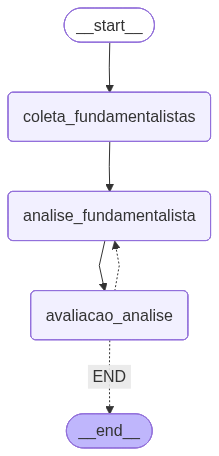

In [27]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import display, Image
import nest_asyncio

nest_asyncio.apply()

display(Image(graph_build.get_graph().draw_mermaid_png()))

In [64]:
data_inicio = "2023-01-01"  
data_fim = "2025-01-31"
response = await graph_build.ainvoke(
            StateClassification(
                {
                    "tic": 'VALE3',
                    "data_inicio": data_inicio,
                    "data_fim": data_fim,
                    "avaliacao_analise": "",
                    "description_avaliacao_analise": "",
                    "interacao": 0,
                }
            )
        )

INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:cerebras.cloud.sdk._base_client:Retrying request to /v1/chat/completions in 0.389462 seconds
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:cerebras.cloud.sdk._base_client:Retrying request to /v1/chat/completions in 0.936401 seconds
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
ERROR:__main__:Erro no llm_pydanticai: Error code: 429 - {'message': 'Tokens per day limit exceeded - too many tokens processed.', 'type': 'too_many_tokens_error', 'param': 'quota', 'code': 'token_quota_exceeded'}
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/c

In [65]:
response

{'classification': None,
 'analysis': None,
 'tic': 'VALE3',
 'dados_fundamentalistas': '|    |   receita_liquida |   ebitda | lucro_por_acao   | datas      | tic   |   alavancagem_financeira |   margem_liquida |   preço_lucro |   preço_vpa |   fluxo_caixa_operacional |   divida_liquida_ebitda |   aumento_reducao_caixa_equivalentes |\n|---:|------------------:|---------:|:-----------------|:-----------|:------|-------------------------:|-----------------:|--------------:|------------:|--------------------------:|------------------------:|-------------------------------------:|\n|  0 |             43840 |    18080 | 2.10             | 2023-03-31 | VALE3 |                     2.34 |            0.386 |          3.87 |        1.68 |                     18970 |                    0.49 |                                 -364 |\n|  1 |             47760 |    18060 | 1.01             | 2023-06-30 | VALE3 |                     2.36 |            0.276 |          5.61 |        1.71 |              

#### Run all tics

In [ ]:
df_tics = pd.read_csv(
            "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv"
        )
list_tics = df_tics["tic"].to_list()
list_tics

In [46]:
import asyncio
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
tics = ["VALE3", "PETR4", "ITUB4", "BBDC4", "ABEV3", 
        "MGLU3", "BBAS3", "GGBR4", "RENT3", "LREN3",
        "PSSA3", "BBSE3", "BRAP4", "VIVT3",]

async def _invoke_tic(tic: str, data_inicio: str = "2023-01-01", data_fim: str = "2025-01-01"):
    try:
        return await graph_build.ainvoke(
            StateClassification(
                {
                    "tic": tic,
                    "data_inicio": data_inicio,
                    "data_fim": data_fim,
                    "avaliacao_analise": "",
                    "description_avaliacao_analise": "",
                    "interacao": 0,
                }
            )
        )
    except Exception as e:
        logger.error(f"Erro ao processar {tic}: {e}")

async def run_all_tics(tics, data_inicio: str = "2023-01-01", data_fim: str = "2025-01-01"):
    tasks = [_invoke_tic(tic, data_inicio, data_fim) for tic in tics]
    results_list = await asyncio.gather(*tasks)
    return dict(zip(tics, results_list))

#results = await run_all_tics()

In [ ]:
results = await run_all_tics(
    #tics=tics, 
    tics=list_tics[:80],
    data_inicio="2023-01-01", 
    data_fim="2025-01-01"
    )

In [ ]:
import asyncio
import time
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

tics = ["VALE3", "PETR4", "ITUB4", "BBDC4", "ABEV3", 
        "MGLU3", "BBAS3", "GGBR4", "RENT3", "LREN3",
        "PSSA3", "BBSE3", "BRAP4", "VIVT3"]

async def _invoke_tic(tic: str, data_inicio: str = "2023-01-01", data_fim: str = "2025-01-01"):
    try:
        start = time.time()
        logger.info(f"🚀 Iniciando {tic}")
        
        result = await graph_build.ainvoke(
            StateClassification({
                "tic": tic,
                "data_inicio": data_inicio,
                "data_fim": data_fim,
                "avaliacao_analise": "",
                "description_avaliacao_analise": "",
                "interacao": 0,
            })
        )
        
        elapsed = time.time() - start
        logger.info(f"✅ {tic} concluído em {elapsed:.2f}s")
        return result
        
    except Exception as e:
        logger.error(f"❌ Erro ao processar {tic}: {e}")
        return None

async def run_all_tics(tics, data_inicio: str = "2023-01-01", data_fim: str = "2025-01-01"):
    start_total = time.time()
    
    tasks = [_invoke_tic(tic, data_inicio, data_fim) for tic in tics]
    results_list = await asyncio.gather(*tasks, return_exceptions=True)
    
    elapsed_total = time.time() - start_total
    logger.info(f"⏱️  Tempo total: {elapsed_total:.2f}s")
    
    return dict(zip(tics, results_list))

# Executar
results = await run_all_tics(
    #tics
    list_tics[:80]
    )

In [ ]:
import asyncio

async def run_all_tics(tics, data_inicio: str = "2023-01-01", data_fim: str = "2025-01-01", max_concurrent: int = 4):
    start_total = time.time()
    
    # Create semaphore to limit concurrent tasks
    semaphore = asyncio.Semaphore(max_concurrent)
    
    async def bounded_invoke(tic):
        async with semaphore:  # Only 4 tasks run simultaneously
            return await _invoke_tic(tic, data_inicio, data_fim)
    
    tasks = [bounded_invoke(tic) for tic in tics]
    results_list = await asyncio.gather(*tasks, return_exceptions=True)
    
    elapsed_total = time.time() - start_total
    logger.info(f"⏱️  Tempo total: {elapsed_total:.2f}s")
    
    return dict(zip(tics, results_list))

# Run with 4 concurrent tasks
results = await run_all_tics(list_tics[:80], max_concurrent=10)

In [ ]:
results = await run_all_tics(list_tics[:10], max_concurrent=10)

In [61]:
results

{'AALR3': {'classification': None,
  'analysis': None,
  'tic': 'AALR3',
  'dados_fundamentalistas': '|    |   receita_liquida |   ebitda | lucro_por_acao   | datas      | tic   |   alavancagem_financeira |   margem_liquida |   preço_lucro |   preço_vpa |   fluxo_caixa_operacional |   divida_liquida_ebitda |   aumento_reducao_caixa_equivalentes |\n|---:|------------------:|---------:|:-----------------|:-----------|:------|-------------------------:|-----------------:|--------------:|------------:|--------------------------:|------------------------:|-------------------------------------:|\n|  0 |            289.65 |    53.4  | -  0.31          | 2023-03-31 | AALR3 |                     2.84 |           -0.225 |        -10.84 |        2.96 |                     44.68 |                    8.6  |                               -64.13 |\n|  1 |            299.42 |    52.25 | -  0.44          | 2023-06-30 | AALR3 |                     2.91 |           -0.253 |         -9.87 |        3.27 | 

In [ ]:
import warnings
warnings.filterwarnings("ignore")
conurrent= [2, 3, 4, 5, 6, 7, 8, 9, 10, 15]
for i in conurrent:
    print(f"Concurrent: {i}")
    print("------------")
    start = time.time()
    results = await run_all_tics(list_tics[:20], max_concurrent=i)
    elapsed = time.time() - start
    print(f"Tempo total: {elapsed:.2f}s")
    print("------------")

### Criando pesos carteira

In [37]:
class StateCarteira(TypedDict):
    tickers_weights: Dict[str, float]
    justification : str 
    analise_avaliador_weights: str
    avaliacao_acoes : str
    correlacao_acoes : str
    interacao : int
    
class CarteiraWeights(BaseModel):
    tickers_weights: Dict[str, float] = Field(description="Tickers and their respective weights.")
    justification : str = Field(description="Justification for the allocation.")

In [38]:
PROMPT_CRIANDO_CARTEIRA = f"""
You are a **quantitative financial consultant specialized in portfolio optimization**, 
with a focus on the Brazilian equities market.

Your goal is to analyze the data provided and propose the **optimal allocation weights (%)** 
for each correlation, and fundamental quality.

**Qualitative Asset Classification:**
{{classificacoes_acoes}}

## 📌 AVAILABLE DATA

<Qualitative Asset Classification>
Each asset has received a fundamental classification according to the following levels:

- **Excellent** — consistently above-average sector indicators; strong growth; low leverage; high profitability.
- **Good** — mostly solid indicators; few points of concern.
- **Fair** — mixed indicators; moderate performance; meaningful points of attention.
- **Poor** — predominantly weak indicators; problematic leverage or profitability.
- **Very Poor** — critical indicators; high deterioration risk.

<Correlation Matrix of Returns>
Use the correlation matrix to measure systemic risk, identify risk clusters, 
and avoid non-obvious concentration.
{{matriz_correlacao}}

</Correlation Matrix of Returns>

{{recomendacao}}

<OPTIMIZATION OBJECTIVES>

1. **Maximize the return/risk balance** (qualitative + quantitative).
2. **Maintain effective diversification**, avoiding excessive concentration.
3. **Prioritize assets with superior classification** (Excellent > Good > Fair).
4. **Minimize weighted correlations** between selected assets.
5. **Avoid low-quality assets**, limiting **Poor + Very Poor to a maximum of 5% combined**, if included at all.

</OPTIMIZATION OBJECTIVES>

<ALLOCATION CONSTRAINTS>

- The sum of all weights **must be exactly 100%**.
- **Minimum weight** per included asset: **5%**.
- **Maximum weight** per asset: **20%**.
- Among assets of the same class (Excellent, Good, Fair), prioritize those with the best **risk/return tradeoff**.
</ALLOCATION CONSTRAINTS>

The justification must relate:
- fundamental quality,
- correlation within the portfolio,
- risk/return profile,
- the asset’s role in diversification.
</REQUIRED RESPONSE FORMAT>

<PORTFOLIO RISK ANALYSIS>
Include the following:
- achieved diversification and presence of clusters,
- weighted average correlation,
- total exposure to Fair / Poor / Very Poor,
- main risks of the portfolio,
- how the proposed allocation mitigates these risks.

</PORTFOLIO RISK ANALYSIS>

"""

In [39]:
RECOMENDACAO_SENIOR = """<PREVIOUS PORTFOLIO EVALUATION & RECOMMENDATIONS>
A senior analyst has reviewed a previous allocation attempt and provided the following feedback.
**YOU MUST INCORPORATE THESE RECOMMENDATIONS** into your new allocation proposal.

{{recomendacao}}

**CRITICAL**: Address each identified issue and implement suggested improvements in your allocation.

</PREVIOUS PORTFOLIO EVALUATION & RECOMMENDATIONS>"""

In [40]:
async def analista_criador_carteira(state):
    correlacao = state.get("correlacao_acoes")
    
    dados_markdown = state.get("avaliacao_acoes")
    
    analise_avaliador_weights = state.get("analise_avaliador_weights")
    
    if analise_avaliador_weights:
        PROMPT_CRIANDO_CARTEIRA_FORMATED = PROMPT_CRIANDO_CARTEIRA.format(classificacoes_acoes=dados_markdown, 
                                                                       matriz_correlacao=correlacao, 
                                                                       recomendacao = RECOMENDACAO_SENIOR.format(recomendacao=analise_avaliador_weights))
    else:
        PROMPT_CRIANDO_CARTEIRA_FORMATED = PROMPT_CRIANDO_CARTEIRA.format(classificacoes_acoes=dados_markdown, 
                                                                       matriz_correlacao=correlacao, 
                                                                       recomendacao = "")
    
    llm = LlmRouter(
        PROMPT_CRIANDO_CARTEIRA_FORMATED,
        CarteiraWeights
        
    )
    
    response= await llm.llm_router()
    response_trat = tratando_resposta_router_llm(response)
    return {"tickers_weights" : response_trat.get("tickers_weights"),
            "justification" : response_trat.get("justification") }
    
    


In [41]:
PROMPT_AVALIADOR_PESOS_CARTEIRA = f"""

You are a **senior portfolio review analyst and risk management specialist**, 
with deep expertise in Brazilian equities markets and quantitative portfolio construction.

Your mission is to **critically evaluate** a proposed portfolio allocation, examining whether 
it genuinely adheres to stated optimization objectives, constraints, and best practices 
in portfolio management.

## INPUTS FOR EVALUATION

<Proposed Portfolio Allocation>
{{alocacao_proposta}}
</Proposed Portfolio Allocation>

<Justified of Proposed Portfolio Allocation>
{{justificativa}}
</Justified of Proposed Portfolio Allocation>

<Original Qualitative Asset Classification>
{{classificacoes_acoes}}
</Original Qualitative Asset Classification>

<Original Correlation Matrix>
{{matriz_correlacao}}
</Original Correlation Matrix>

<Stated Optimization Objectives>
1. Maximize return/risk balance (qualitative + quantitative)
2. Maintain effective diversification
3. Prioritize assets with superior classification
4. Minimize weighted correlations
5. Limit Poor + Very Poor assets to maximum 5% combined
</Stated Optimization Objectives>

<Stated Constraints>
- Total allocation must equal 100%
- Minimum weight per asset: 5%
- Maximum weight per asset: 20%
- Prioritize best risk/return within same quality class
</Stated Constraints>

---

## 🔍 EVALUATION DIMENSIONS

### 1. **CONSTRAINT COMPLIANCE** (Pass/Fail)
Verify mathematically:
- [ ] Does allocation sum to exactly 100%?
- [ ] Are all individual weights between 5% and 20%?
- [ ] Is Poor + Very Poor exposure ≤ 5%?
- [ ] Are there any calculation errors?

**Score: X/4 constraints met**

---

### 2. **OPTIMIZATION QUALITY** (Score: 0-10)

#### 2.1 Quality Prioritization
- What % is allocated to Excellent assets?
- What % is allocated to Good assets?
- What % is allocated to Fair assets?
- Is there excessive weight on lower-quality assets?
- Are higher-quality assets genuinely prioritized?

**Score: __/10**

#### 2.2 Diversification Effectiveness
- How many assets are included?
- Is concentration excessive (e.g., 3 assets > 60% combined)?
- Are there correlation clusters not addressed?
- Calculate Herfindahl-Hirschman Index (HHI) if applicable
- Are sector/industry concentrations mentioned and managed?

**Score: __/10**

#### 2.3 Correlation Management
- What is the weighted average correlation of the portfolio?
- Are highly correlated assets (>0.7) over-represented?
- Does the allocation genuinely reduce systemic risk?
- Are uncorrelated/negatively correlated assets utilized?

**Score: __/10**

---

### 3. **JUSTIFICATION COHERENCE** (Score: 0-10)

For each allocated asset, verify if justification includes:
- [ ] Explicit reference to fundamental quality classification
- [ ] Discussion of correlation role in portfolio context
- [ ] Clear risk/return rationale
- [ ] Diversification contribution explanation

Are justifications:
- Specific and data-driven?
- Generic and repetitive?
- Contradictory to the allocation itself?

**Score: __/10**

---

### 4. **RISK ANALYSIS DEPTH** (Score: 0-10)

Evaluate if the risk analysis addressed:
- [ ] Diversification level achieved
- [ ] Presence and impact of correlation clusters
- [ ] Weighted average correlation calculation
- [ ] Total exposure to Fair/Poor/Very Poor
- [ ] Main portfolio risks identified
- [ ] Mitigation strategies explained

Is the risk analysis:
- Comprehensive and quantitative?
- Superficial or qualitative only?
- Missing critical risk factors?

**Score: __/10**

---

## 📋 REQUIRED OUTPUT FORMAT

### **EXECUTIVE SUMMARY**
[2-3 sentences: Overall assessment of portfolio quality]

---

### **CONSTRAINT COMPLIANCE CHECK**
| Constraint | Met? | Details |
|------------|------|---------|
| Sum = 100% | ✓/✗ | Actual: __% |
| Min 5% per asset | ✓/✗ | Violations: __ |
| Max 30% per asset | ✓/✗ | Violations: __ |
| Poor+Very Poor ≤5% | ✓/✗ | Actual: __% |

**Result: PASS / FAIL**

---

### **QUANTITATIVE SCORES**

| Dimension | Score | Justification |
|-----------|-------|---------------|
| Quality Prioritization | __/10 | |
| Diversification | __/10 | |
| Correlation Management | __/10 | |
| Justification Coherence | __/10 | |
| Risk Analysis Depth | __/10 | |
| **OVERALL SCORE** | **__/50** | |

---

### **CRITICAL ISSUES IDENTIFIED**

1. **[Issue Category]**: [Specific problem with evidence]
2. **[Issue Category]**: [Specific problem with evidence]
3. ...

---

### **ACTIONABLE RECOMMENDATIONS**

Provide 3-5 specific, implementable improvements:

1. **[Recommendation]**: [Why and how to implement]
2. **[Recommendation]**: [Why and how to implement]
3. ...

---

### **ALTERNATIVE ALLOCATION SUGGESTION** (if score < 35/50)

If the proposed portfolio has significant flaws, suggest concrete adjustments:

| Asset | Current % | Suggested % | Rationale |
|-------|-----------|-------------|-----------|
| ASSET1 | X% | Y% | ... |
| ASSET2 | X% | Y% | ... |
| ... | | | |

---

## ⚠️ EVALUATION PRINCIPLES

- **Be objective and evidence-based**: Use calculations, not opinions
- **Be constructive, not destructive**: Highlight what works AND what doesn't
- **Be specific**: "Correlation too high" → "Weighted avg correlation of 0.82 exceeds optimal range of 0.3-0.5"
- **Be fair**: Acknowledge trade-offs and constraints in portfolio construction
- **Be actionable**: Every criticism should have a clear improvement path

---

**REMEMBER**: A portfolio can meet all constraints and still be suboptimal. 
Your job is to evaluate **how well** objectives were achieved, not just **if** constraints were met.
"""

In [42]:
async def analista_avaliador_peso_carteira(state):
    
    alocacao_proposta = state.get("tickers_weights")
    
    justificativa = state.get("justification")
    
    correlacao = state.get("correlacao_acoes")
    
    dados_markdown = state.get("avaliacao_acoes")
    
    interacao = state.get("interacao", 0)
    
    PROMPT_AVALIADOR_PESOS_CARTEIRA_formatted = PROMPT_AVALIADOR_PESOS_CARTEIRA.format(
                                                alocacao_proposta=alocacao_proposta,
                                                justificativa= justificativa,
                                                classificacoes_acoes=dados_markdown,
                                                matriz_correlacao=correlacao)
    
    llm = LlmRouter(
        PROMPT_AVALIADOR_PESOS_CARTEIRA_formatted,
    
        
    )
    response= await llm.llm_router()
    
    new_interacao = interacao + 1
    
    return {"analise_avaliador_weights" : response,
            "interacao": new_interacao}
    
    

In [43]:
def should_continue(state) -> Literal["END", "analista_avaliador_peso_carteira"]:
    interacao = state.get("interacao")
    if interacao >= 3:  
        return "END"
    return "analista_avaliador_peso_carteira"

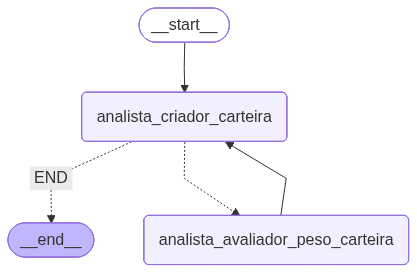

In [44]:
graph_weights = StateGraph(StateCarteira)

graph_weights.add_node("analista_criador_carteira", analista_criador_carteira)

graph_weights.add_node("analista_avaliador_peso_carteira", analista_avaliador_peso_carteira)

graph_weights.set_entry_point("analista_criador_carteira")

graph_weights.add_edge("analista_avaliador_peso_carteira", "analista_criador_carteira")

graph_weights.add_conditional_edges("analista_criador_carteira", should_continue, {
    "analista_avaliador_peso_carteira": "analista_avaliador_peso_carteira",
    "END": END
})

graph_weights_build = graph_weights.compile()

graph_weights_build

In [ ]:
"""response_pesos = await graph_weights_build.ainvoke(
    StateCarteira({
    "justification" : "",
    "avaliacao_acoes": dados_markdown,
    "correlacao_acoes": correlacao.to_markdown(),
    "interacao" : 0
    }))"""

### Avaliando o agente ao longo do tempo

In [169]:
df_tics = pd.read_csv(
            "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv"
        )
list_tics = df_tics["tic"].to_list()
list_tics


['AALR3',
 'ABEV3',
 'AFLT3',
 'AGRO3',
 'AGXY3',
 'AHEB3',
 'ALPA3',
 'ALPA4',
 'ALPK3',
 'ALLD3',
 'ALOS3',
 'AMBP3',
 'AMAR3',
 'AMER3',
 'ANIM3',
 'ASAI3',
 'AURE3',
 'AVLL3',
 'AZEV3',
 'AZUL4',
 'AZZA3',
 'BALM4',
 'BAUH4',
 'BAZA3',
 'BBAS3',
 'BBSE3',
 'BBDC3',
 'BBDC4',
 'BGIP3',
 'BGIP4',
 'BIOM3',
 'BLAU3',
 'BMEB3',
 'BMEB4',
 'BMKS3',
 'BMIN3',
 'BMIN4',
 'BMOB3',
 'BPAN4',
 'BPAC11',
 'BPAC3',
 'BPAC5',
 'BRAP3',
 'BRAP4',
 'BRAV3',
 'BRBI11',
 'BRFS3',
 'BRKM3',
 'BRKM5',
 'BRST3',
 'BRSR3',
 'BRSR6',
 'BSLI3',
 'BSLI4',
 'CAMB3',
 'CAML3',
 'CASH3',
 'CCRO3',
 'CEAB3',
 'CEBR6',
 'CEDO3',
 'CEDO4',
 'CGAS3',
 'CGAS5',
 'CGRA4',
 'CLSC4',
 'CMIG3',
 'CMIG4',
 'COGN3',
 'CRFB3',
 'CSAN3',
 'CSMG3',
 'CSNA3',
 'CSUD3',
 'CYRE3',
 'DIRR3',
 'DXCO3',
 'EALT3',
 'EALT4',
 'ECOR3',
 'EGIE3',
 'ELET3',
 'ELET6',
 'EMBR3',
 'ENEV3',
 'ENGI11',
 'ENGI3',
 'ENGI4',
 'EQTL3',
 'ESPA3',
 'EZTC3',
 'FESA3',
 'FESA4',
 'FIQE3',
 'FLRY3',
 'FRAS3',
 'FRIO3',
 'GGBR3',
 'GGBR4',
 'GOAU3

In [164]:
import yfinance as yf
import pandas as pd
from typing import List

tics = ["VALE3", "PETR4", "ITUB4", "BBDC4", "ABEV3", 
        "MGLU3", "BBAS3", "GGBR4", "RENT3", "LREN3",
        "PSSA3", "B3SA3", "BBSE3", "BRAP4", "VIVT3"]

def correlacao(tics:List[str]):
        tics_yf = [tic + ".SA" for tic in tics]

        # Baixa os preços de fechamento ajustados
        df = yf.download(tics_yf, start="2023-01-01", end="2025-01-01", interval="1mo")["Close"]

        # Calcula os retornos diários
        returns = df.pct_change().dropna()

        # Calcula a matriz de correlação
        correlacao = returns.corr()

        return correlacao.to_markdown()

In [166]:
def transformando_data_frame_para_markdown(results):
    results_pd = pd.DataFrame.from_dict(results).T
    dados_markdown = results_pd.loc[:, ["classification", "analysis"]].reset_index().rename(columns={"index": "tic"}).to_markdown()
    return dados_markdown

In [ ]:
results = await run_all_tics(tics=list_tics, data_inicio="2023-01-01", data_fim="2025-01-01")

INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:__main__:Iniciando roteamento LLM
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"


## Tool metrics

In [119]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

def get_ibov_tickers_from_statusinvest():
    url = "https://statusinvest.com.br/indices/ibovespa"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    }
    r = requests.get(url, headers=headers)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    # A página exibe os tickers dentro de elementos com classe .ticker (como você mencionou)
    tickers = []
    for elem in soup.select(".main-list .ticker"):
        t = elem.get_text(strip=True)
        # Alguns podem ter espaço ou texto adicional — limpar
        if t:
            tickers.append(t + ".SA")  # se quiser no formato Yahoo Finance

    tickers = list(dict.fromkeys(tickers))  # remove duplicados preservando ordem
    return tickers

In [120]:
tickers = get_ibov_tickers_from_statusinvest()

In [ ]:
tickers

In [122]:
from datetime import datetime

def validate_date(date_str: str, field_name):
    try:
            datetime.strptime(date_str, "%Y-%m-%d")
    except ValueError:
        raise ValueError(
            f"Erro: '{field_name}' deve estar no formato YYYY-MM-DD. "
            f"Valor recebido: {date_str}"
        )

In [123]:
import os
import sys
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
from typing import List, Optional

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

#from src.utils import validate_date

def fetch_data(tickers: List[str], start: str, end: Optional[str] = None) -> pd.DataFrame:
    if start is None:
        raise ValueError("O parâmetro 'start' é obrigatório.")
    
    validate_date(start, "start")

    if end is None:
        end = datetime.today().strftime("%Y-%m-%d")
    else:
        validate_date(end, "end")

    if start >= end:
        raise ValueError(f"A data inicial ({start}) deve ser anterior à data final ({end.strftime('%Y-%m-%d')}).")
    
    df = yf.download(tickers, start=start, end=end, progress=False)["Close"]

    df = df.dropna(how="all", axis=1)

    if df.empty:
        raise ValueError("Nenhum dado retornado. Verifique os tickers ou intervalo de datas.")
    
    return df

In [124]:
data_precos = fetch_data(tickers, "2022-01-01")

In [125]:
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize

def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

In [126]:
data_precos.drop(columns=["AURE3.SA", "EMBJ3.SA", "MOTV3.SA", "NATU3.SA"], inplace=True, axis=1) 

In [127]:
weights_markowitz, markowitz_cr = markowitz_opt(data_precos.pct_change().dropna())

In [128]:
weights_markowitz

Ticker,ABEV3.SA,ALOS3.SA,ASAI3.SA,AXIA3.SA,AXIA6.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBDC3.SA,BBDC4.SA,...,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VAMO3.SA,VBBR3.SA,VIVA3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0
2022-01-05,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0
2022-01-06,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0
2022-01-07,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0
2022-01-10,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-18,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0
2025-11-19,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0
2025-11-21,0.111152,2.699703e-19,0.0,2.919473e-18,0.0,2.754932e-18,5.104183e-18,3.913259e-18,0.0,2.681889e-18,...,1.326582e-18,0.0,9.504055e-19,0.058834,0.0,0.0,2.289440e-18,0.044056,0.032337,0.0


In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        dr = daily_returns(p)
        metrics[col] = {
            "ann_vol": annualized_volatility(dr),
            "ann_mean_ret": annualized_mean_return(dr),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(dr)
        }
    return pd.DataFrame(metrics).T

In [131]:
metrics = compute_metrics(data_precos)

In [135]:
type(metrics)

pandas.core.frame.DataFrame

In [159]:
len(metrics.to_markdown())

9439

## Todo lists

In [39]:
WRITE_TODOS_DESCRIPTION = """Create and manage structured task lists for tracking progress through complex workflows.

## When to Use
- Multi-step or non-trivial tasks requiring coordination
- When user provides multiple tasks or explicitly requests todo list  
- Avoid for single, trivial actions

## Structure
- Maintain one list containing multiple todo objects (content, status, id)
- Use clear, actionable content descriptions
- Status must be: pending, in_progress, or completed

## Best Practices  
- Only one in_progress task at a time
- Mark completed immediately when task is fully done
- Always send the full updated list when making changes
- Prune irrelevant items to keep list focused

## Progress Updates
- Call TodoWrite again to change task status or edit content
- Reflect real-time progress; don't batch completions  
- If blocked, keep in_progress and add new task describing blocker

## Parameters
- todos: List of TODO items with content and status fields

## Returns
Updates agent state with new todo list."""

In [40]:
"""TODO management tools for task planning and progress tracking.

This module provides tools for creating and managing structured task lists
that enable agents to plan complex workflows and track progress through
multi-step operations.
"""

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
import operator
from typing import TypedDict, Literal, List, Annotated
from langchain_core.messages import BaseMessage

class Todo(TypedDict):
    """A structured task item for tracking progress through complex workflows.

    Attributes:
        content: Short, specific description of the task
        status: Current state - pending, in_progress, or completed
    """

    content: str
    status: Literal["pending", "in_progress", "completed"]
    

class DeepInvestiment(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    todos: list[Todo]


@tool(description=WRITE_TODOS_DESCRIPTION,parse_docstring=True)
def write_todos(
    todos: list[Todo], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Args:
        todos: List of Todo items with content and status
        tool_call_id: Tool call identifier for message response

    Returns:
        Command to update agent state with new TODO list
    """
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list to {todos}", tool_call_id=tool_call_id)
            ],
        }
    )


@tool(parse_docstring=True)
def read_todos(
    state: Annotated[DeepInvestiment, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> str:
    """Read the current TODO list from the agent state.

    This tool allows the agent to retrieve and review the current TODO list
    to stay focused on remaining tasks and track progress through complex workflows.

    Args:
        state: Injected agent state containing the current TODO list
        tool_call_id: Injected tool call identifier for message tracking

    Returns:
        Formatted string representation of the current TODO list
    """
    todos = state.get("todos", [])
    if not todos:
        return "No todos currently in the list."

    result = "Current TODO List:\n"
    for i, todo in enumerate(todos, 1):
        status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
        emoji = status_emoji.get(todo["status"], "❓")
        result += f"{i}. {emoji} {todo['content']} ({todo['status']})\n"

    return result.strip()

In [41]:
TODO_USAGE_INSTRUCTIONS = """Based upon the user's request:
1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.
2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan. 
3. Reflect on what you've done and the TODO.
4. Mark you task as completed, and proceed to the next TODO.
5. Continue this process until you have completed all TODOs.

IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY user request.
IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have to keep track of.
"""

In [42]:
prompt_agent_investimento = """
<Task>
You are whose mission is to help the user .
Context: today's date is {date}. Assume the user speaks Portuguese unless otherwise specified.

<Capabilities / Tools>
You have access to the following tools:

1. **write_todos** — Manage or update the agent's TODO list for task planning and progress tracking.
   • Limit: up to **3 calls per session** (initial plan + mid-update + final review).

2. **read_todos** — Read the current TODO list to maintain context and focus.
   • Limit: up to **5 calls per session** (use only when switching context or resuming work).

3. **web_search** — Retrieve verified external information (APIs, frameworks, recent updates).
   • Limit: based on complexity level:
     - Simple tasks → **max 1 call**
     - Normal tasks → **max 2 calls**
     - Complex/research-heavy tasks → **max 3 calls**
   • Never exceed 3 total web_search calls in one user task.

4. **think_tool** — Reflect after each search or major step; summarize findings, identify gaps, and plan next actions.
   • Mandatory after every web_search call.
   • Limit: **equal to number of web_search calls + 2** (for initial and final reflections).



<Show Your Thinking>
After each **web_search**, use **think_tool** to summarize:
- Key findings
- Missing information
- Whether another search is needed or if the task can proceed
- How the new info affects the plan



</prompt_agent_code>
"""


In [43]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents import create_agent
from tavily import TavilyClient
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
import sys
from datetime import datetime


load_dotenv()

tavily_client = TavilyClient()

@tool(parse_docstring=True)
def web_search(query: str, max_results: int = 5, include_images: bool = False) -> list[dict[str, str]]:
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.
        max_results: The maximum number of search results to return.
        include_images: Whether to include images in the search results.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    params = {}
    api_key = os.getenv("TAVILY_API_KEY")
    if not api_key:
        raise ValueError("TAVILY_API_KEY not found in environment variables.")
    params['api_key'] = api_key

    #client = TavilyClient(api_key)

    api_base_url = os.getenv("DLAI_TAVILY_BASE_URL")
    if api_base_url:
        params['api_base_url'] = api_base_url

    client = TavilyClient(api_key=api_key, api_base_url=api_base_url)

    try:
        response = client.search(
            query=query,
            max_results=max_results,
            include_images=include_images
        )

        results = []
        for r in response.get("results", []):
            results.append({
                "title": r.get("title", ""),
                "content": r.get("content", ""),
                "url": r.get("url", "")
            })

        if include_images:
            for img_url in response.get("images", []):
                results.append({"image_url": img_url})

        return results

    except Exception as e:
        return [f'An Error occurred: {e} with the Tavily API. Please try again later.']


@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"


def get_today_str() -> str:
    """Get current date in a human-readable format."""
    if sys.platform.startswith("win"):
        return datetime.now().strftime("%a %b %#d, %Y")
    else:
        return datetime.now().strftime("%a %b %-d, %Y")

model = ChatNVIDIA(
    model="qwen/qwen3-next-80b-a3b-instruct",
)

tools = [write_todos, web_search, read_todos,think_tool]

current_date = get_today_str()
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Create agent
agent = create_agent(
    model,
    tools,
    system_prompt=TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "\n\n"
    + prompt_agent_investimento.format(date=get_today_str())
    ,
    state_schema=DeepInvestiment,
    #checkpointer=MemorySaver()
    
)



In [44]:
config = {"configurable": {"user_id": "1", "thread_id": "1"}}

In [47]:
from langchain_core.messages import HumanMessage
rodar = True
if rodar:

    result = agent.invoke(
        {
            "messages": 
                [HumanMessage(role="user",
                            content=""" 
                            Tenho 100000 para investir, monte uma carteira diversificada com ações do Ibovespa.
                                """)],
            
        }, #config=config
    )


In [48]:
from utils import format_messages
if rodar:
    format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│                                                                                                                 │
│                             Tenho 100000 para investir, monte uma carteira diversificada com ações do Ibovespa. │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Pesquisar as principais ações do Ibovespa com bom desempenho histórico e baixa volatilidade", │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Identificar setores representativos no Ibovespa para diversificação da carteira",             │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Construir uma carteira diversificada com 8-12 ações, distribuindo o capital de R$100.000",    │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Revisar e justificar a alocação final da carteira, incluindo riscos e recomendações",         │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_749b17acecdf466ca574927a                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Pesquisar as principais ações do Ibovespa com bom desempenho histórico e     │
│ baixa volatilidade', 'status': 'pending'}, {'content': 'Identificar setores representativos no Ibovespa para    │
│ diversificação da carteira', 'status': 'pending'}, {'content': 'Construir uma carteira diversificada com 8-12   │
│ ações, distribuindo o capital de R$100.000', 'status': 'pending'}, {'content': 'Revisar e justificar a alocação │
│ final da carteira, incluindo riscos e recomendações', 'status': 'pending'}]                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: call_0a6e42f840154c8e825aecda                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Current TODO List:                                                                                              │
│ 1. ⏳ Pesquisar as principais ações do Ibovespa com bom desempenho histórico e baixa volatilidade (pending)     │
│ 2. ⏳ Identificar setores representativos no Ibovespa para diversificação da carteira (pending)                 │
│ 3. ⏳ Construir uma carteira diversificada com 8-12 ações, distribuindo o capital de R$100.000 (pending)        │
│ 4. ⏳ Revisar e justificar a alocação final da carteira, incluindo riscos e recomendações (pending)             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "Foi encontrada a composição atualizada do índice IBLV (Ibovespa Smart Low Volatility) da B3,   │
│ com dados de 21/11/2025. As 20 ações que compõem o índice são as de menor volatilidade no Ibovespa, com alta    │
│ liquidez e participação de grandes empresas como Petrobras (PETR4), Itaú Unibanco (ITUB4), Vale (VALE3), Banco  │
│ do Brasil (BBAS3), Eletrobras (ELET6), Cielo (CIEL3) e Bradesco (BBDC4). Além disso, ações com alto dividend    │
│ yield como MRFG3, DIRR3 e CMIN3 também estão presentes. Combinando os dados do IBLV com os dividend yield mais  │
│ altos, é possível construir uma carteira diversificada de 10 ações com baixa volatilidade, sólida fundamentação │
│ e bom retorno por dividendo. Agora, posso prosseguir com a construção da carteira de R$100.000, distribuindo o  │
│ capital entre essas ações com base em liquidez, participação no índice e yield. O próximo passo é definir a     │
│ alocação final, considerando diversificação por setor e limite de exposição individual."                        │
│ }                                                                                                               │
│    ID: call_3bb981572f5f426a99100aa1                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: Foi encontrada a composição atualizada do índice IBLV (Ibovespa Smart Low Volatility) da   │
│ B3, com dados de 21/11/2025. As 20 ações que compõem o índice são as de menor volatilidade no Ibovespa, com     │
│ alta liquidez e participação de grandes empresas como Petrobras (PETR4), Itaú Unibanco (ITUB4), Vale (VALE3),   │
│ Banco do Brasil (BBAS3), Eletrobras (ELET6), Cielo (CIEL3) e Bradesco (BBDC4). Além disso, ações com alto       │
│ dividend yield como MRFG3, DIRR3 e CMIN3 também estão presentes. Combinando os dados do IBLV com os dividend    │
│ yield mais altos, é possível construir uma carteira diversificada de 10 ações com baixa volatilidade, sólida    │
│ fundamentação e bom retorno por dividendo. Agora, posso prosseguir com a construção da carteira de R$100.000,   │
│ distribuindo o capital entre essas ações com base em liquidez, participação no índice e yield. O próximo passo  │
│ é definir a alocação final, considerando diversificação por setor e limite de exposição individual.             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Pesquisar as principais ações do Ibovespa com bom desempenho histórico e baixa volatilidade", │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Identificar setores representativos no Ibovespa para diversificação da carteira",             │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Construir uma carteira diversificada com 8-12 ações, distribuindo o capital de R$100.000",    │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Revisar e justificar a alocação final da carteira, incluindo riscos e recomendações",         │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_c7a72ab5892542c88612e186                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Pesquisar as principais ações do Ibovespa com bom desempenho histórico e     │
│ baixa volatilidade', 'status': 'completed'}, {'content': 'Identificar setores representativos no Ibovespa para  │
│ diversificação da carteira', 'status': 'completed'}, {'content': 'Construir uma carteira diversificada com 8-12 │
│ ações, distribuindo o capital de R$100.000', 'status': 'in_progress'}, {'content': 'Revisar e justificar a      │
│ alocação final da carteira, incluindo riscos e recomendações', 'status': 'pending'}]                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Com base nas pesquisas realizadas, aqui está a proposta de **carteira diversificada de ações do Ibovespa** para │
│ um investimento de **R$100.000**, com foco em **baixa volatilidade, alto dividend yield e solidez               │
│ fundamental**, utilizando como base o índice **IBLV (Ibovespa Smart Low Volatility)** e as ações com os         │
│ melhores rendimentos de dividendos em 2025.                                                                     │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 📊 **Carteira Diversificada – R$100.000 (10 ações)**                                                        │
│                                                                                                                 │
│ | Código | Empresa | Setor | Dividend Yield (2025) | Participação na Carteira | Valor Investido | Número de     │
│ Ações (estimado) |                                                                                              │
│ |--------|---------|-------|------------------------|--------------------------|-----------------|------------- │
│ ---------------|                                                                                                │
│ | **PETR4** | Petrobras | Energia | 9,5% | 15% | R$15.000 | ~300 |                                              │
│ | **ITUB4** | Itaú Unibanco | Financeiro | 10,2% | 12% | R$12.000 | ~350 |                                      │
│ | **BBAS3** | Banco do Brasil | Financeiro | 12,0% | 10% | R$10.000 | ~280 |                                    │
│ | **VALE3** | Vale | Mineração | 8,7% | 12% | R$12.000 | ~180 |                                                 │
│ | **ELET6** | Eletrobras | Energia | 7,5% | 8% | R$8.000 | ~400 |                                               │
│ | **CIEL3** | Cielo | Tecnologia | 6,8% | 8% | R$8.000 | ~500 |                                                 │
│ | **MRFG3** | Marfrig | Alimentos | 19,6% | 10% | R$10.000 | ~250 |                                             │
│ | **DIRR3** | Direcional | Logística | 12,3% | 8% | R$8.000 | ~150 |                                            │
│ | **BBDC4** | Bradesco | Financeiro | 11,0% | 8% | R$8.000 | ~300 |                                             │
│ | **CMIN3** | CSN Mineração | Mineração | 14,0% | 9% | R$9.000 | ~200 |                                         │
│                                                                                                                 │
│ **Total:** R$100.000                                                                                            │
│ **Dividend Yield médio da carteira:** ~11,2% ao ano                                                             │
│ **Setores representados:** Financeiro (3), Energia (2), Mineração (2), Alimentos (1), Logística (1), Tecnologia │
│ (1) → **Excelente diversificação**                                                                              │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### ✅ **Justificativa da Estratégia**                                                                          │
│                                                                                                                 │
│ - **Baixa volatilidade:** Todas as ações são componentes 